In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from imblearn.pipeline import Pipeline
from collections import Counter
from smote import DynamicSMOTE

In [2]:
# 1. Gerando dados com 3 classes, desbalanceadas
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    n_classes=3,
    weights=[0.8, 0.1, 0.1],
    class_sep=1.1,
    random_state=42
)

print("Distribuição original:", Counter(y).items())

array1 = [(10, 63), (11, 60), (12, 36), (13, 21), (14, 75), (15, 54), (16, 48), (17, 21), (18, 15), (19, 15), (1, 78), (20, 273), (21, 120), (22, 132), (23, 99), (24, 15), (25, 15), (26, 30), (27, 126), (28, 15), (29, 12), (2, 42), (30, 12), (31, 42), (32, 72), (33, 96), (34, 180), (35, 42), (36, 18), (37, 27), (38, 12), (39, 33), (3, 165), (40, 12), (41, 30), (42, 54), (43, 27), (44, 18), (45, 51), (46, 12), (47, 108), (48, 12), (49, 177), (4, 15), (50, 24), (51, 15), (52, 12), (53, 150), (54, 24), (55, 234), (5, 84), (6, 24), (7, 24), (8, 60), (9, 24)]


print(sorted(array1, key=lambda x: x[1]))

strategy = {
            cls: 40 for cls, count in array1
            if count <= 30
        }

strategyv2 = {
            cls: count + 10 for cls, count in array1
            if count <= 30
        }


print(len(strategy))
print(strategyv2)
ordenado = dict(sorted(strategyv2.items(), key=lambda item: item[1]))
print(ordenado)

Distribuição original: dict_items([(0, 80), (2, 10), (1, 10)])
[(29, 12), (30, 12), (38, 12), (40, 12), (46, 12), (48, 12), (52, 12), (18, 15), (19, 15), (24, 15), (25, 15), (28, 15), (4, 15), (51, 15), (36, 18), (44, 18), (13, 21), (17, 21), (50, 24), (54, 24), (6, 24), (7, 24), (9, 24), (37, 27), (43, 27), (26, 30), (41, 30), (39, 33), (12, 36), (2, 42), (31, 42), (35, 42), (16, 48), (45, 51), (15, 54), (42, 54), (11, 60), (8, 60), (10, 63), (32, 72), (14, 75), (1, 78), (5, 84), (33, 96), (23, 99), (47, 108), (21, 120), (27, 126), (22, 132), (53, 150), (3, 165), (49, 177), (34, 180), (55, 234), (20, 273)]
27
{13: 31, 17: 31, 18: 25, 19: 25, 24: 25, 25: 25, 26: 40, 28: 25, 29: 22, 30: 22, 36: 28, 37: 37, 38: 22, 40: 22, 41: 40, 43: 37, 44: 28, 46: 22, 48: 22, 4: 25, 50: 34, 51: 25, 52: 22, 54: 34, 6: 34, 7: 34, 9: 34}
{29: 22, 30: 22, 38: 22, 40: 22, 46: 22, 48: 22, 52: 22, 18: 25, 19: 25, 24: 25, 25: 25, 28: 25, 4: 25, 51: 25, 36: 28, 44: 28, 13: 31, 17: 31, 50: 34, 54: 34, 6: 34, 7:

In [31]:
# 2. Pipeline com DynamicSMOTE + SVC
pipeline = Pipeline([
    ("smote", DynamicSMOTE()),
    ("clf", SVC(probability=True))
])

# 3. Grid de parâmetros para o GridSearchCV
param_grid = {
    "smote__minimo_amostras": [10, 20],
    "smote__quantidade_gerada": [100],
    "clf__C": [1, 10],
    "clf__kernel": ["rbf", "linear"],
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="f1_macro",
    verbose=1,
    n_jobs=-1
)

# 4. Treinamento
grid.fit(X, y)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}
{np.int64(2): 100, np.int64(1): 100}


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('smote', DynamicSMOTE()),
                                       ('clf', SVC(probability=True))]),
             n_jobs=-1,
             param_grid={'clf__C': [1, 10], 'clf__kernel': ['rbf', 'linear'],
                         'smote__minimo_amostras': [10, 20],
                         'smote__quantidade_gerada': [100]},
             scoring='f1_macro', verbose=1)

In [32]:

# 5. Resultados
print("Melhores parâmetros:", grid.best_params_)
print("F1 macro score (validação):", grid.best_score_)

y_pred = grid.predict(X)
print("\nClassification report (no próprio treino):")
print(classification_report(y, y_pred))

Melhores parâmetros: {'clf__C': 1, 'clf__kernel': 'rbf', 'smote__minimo_amostras': 10, 'smote__quantidade_gerada': 100}
F1 macro score (validação): 1.0

Classification report (no próprio treino):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



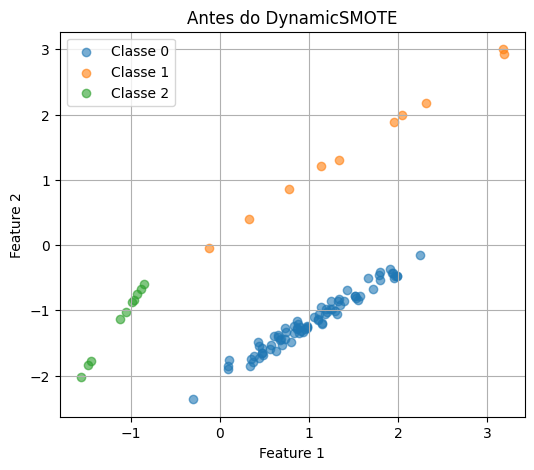

In [33]:
# 6. Visualização antes e depois do SMOTE
def plot_data(X, y, title):
    plt.figure(figsize=(6, 5))
    for label in np.unique(y):
        idx = y == label
        plt.scatter(X[idx, 0], X[idx, 1], label=f"Classe {label}", alpha=0.6)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True)


# Plot original
plot_data(X, y, "Antes do DynamicSMOTE")

{np.int64(2): 100, np.int64(1): 100}


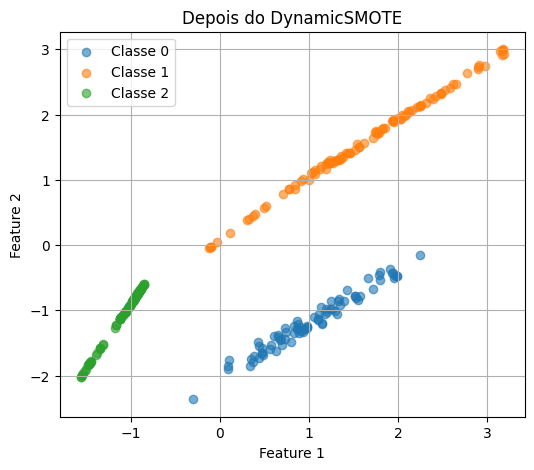

In [34]:


# Gerar os dados balanceados separadamente (apenas para plot)
best_smote = DynamicSMOTE(
    minimo_amostras=grid.best_params_["smote__minimo_amostras"],
    quantidade_gerada=grid.best_params_["smote__quantidade_gerada"],
    random_state=42
)
X_res, y_res = best_smote.fit_resample(X, y)

plot_data(X_res, y_res, "Depois do DynamicSMOTE")

plt.show()

Distribuição original: Counter({np.int64(0): 95, np.int64(1): 5})
Fitting 3 folds for each of 4 candidates, totalling 12 fits
{np.int64(1): 100}
{np.int64(1): 100}
{np.int64(1): 100}
{np.int64(1): 100}
{np.int64(1): 100}
{np.int64(1): 100}
{np.int64(1): 100}
{np.int64(1): 100}
{np.int64(1): 100}
{np.int64(1): 100}
{np.int64(1): 100}
{np.int64(1): 100}
{np.int64(1): 100}
{np.int64(1): 100}
Distribuição após SMOTE: Counter({np.int64(1): 100, np.int64(0): 95})


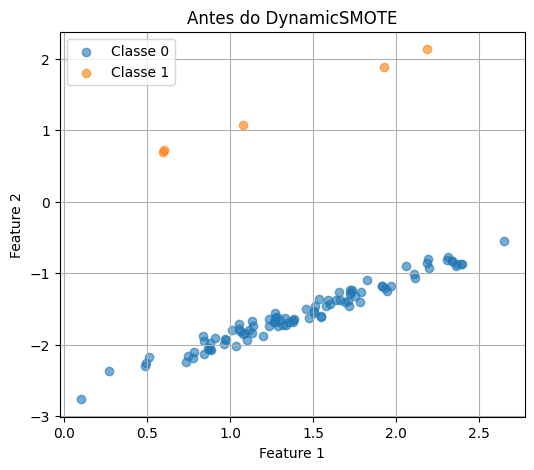

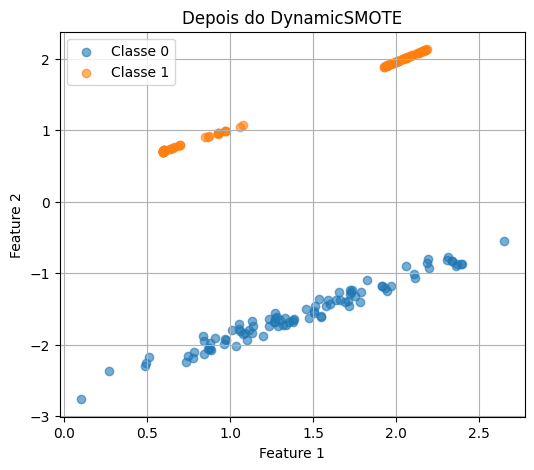

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from collections import Counter

# 1. Gera dados com 2 classes (classe 1 tem só 5 amostras)
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    n_classes=2,
    weights=[0.95, 0.05],  # Classe 0: 95 amostras, Classe 1: 5 amostras
    class_sep=1.5,
    random_state=42
)

print("Distribuição original:", Counter(y))


# 2. Pipeline com DynamicSMOTE + SVC
pipeline = Pipeline([
    ("smote", DynamicSMOTE()),
    ("clf", SVC(probability=True))
])

# 3. Grid de parâmetros para o GridSearchCV
param_grid = {
    "smote__minimo_amostras": [5],
    "smote__quantidade_gerada": [100],
    "smote__k_neighbors": [1],
    "clf__C": [1, 10],
    "clf__kernel": ["rbf", "linear"],
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="f1_macro",
    verbose=1,
    n_jobs=-1
)

# 4. Treinamento
classifier = grid.fit(X, y)


# 2. Aplica DynamicSMOTE diretamente
minimo = classifier.best_params_.get('smote__minimo_amostras')
quantidade = classifier.best_params_.get('smote__quantidade_gerada')
k_neighbors = classifier.best_params_.get('smote__k_neighbors')
random_state = classifier.best_params_.get('smote__random_state')

smote = DynamicSMOTE(random_state, minimo, quantidade, k_neighbors)
X_res, y_res = smote.fit_resample(X, y)

print("Distribuição após SMOTE:", Counter(y_res))

# 3. Visualização
def plot_data(X, y, title):
    plt.figure(figsize=(6, 5))
    for label in np.unique(y):
        idx = y == label
        plt.scatter(X[idx, 0], X[idx, 1], label=f"Classe {label}", alpha=0.6)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True)

plot_data(X, y, "Antes do DynamicSMOTE")




plot_data(X_res, y_res, "Depois do DynamicSMOTE")
plt.show()
